In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches

import os


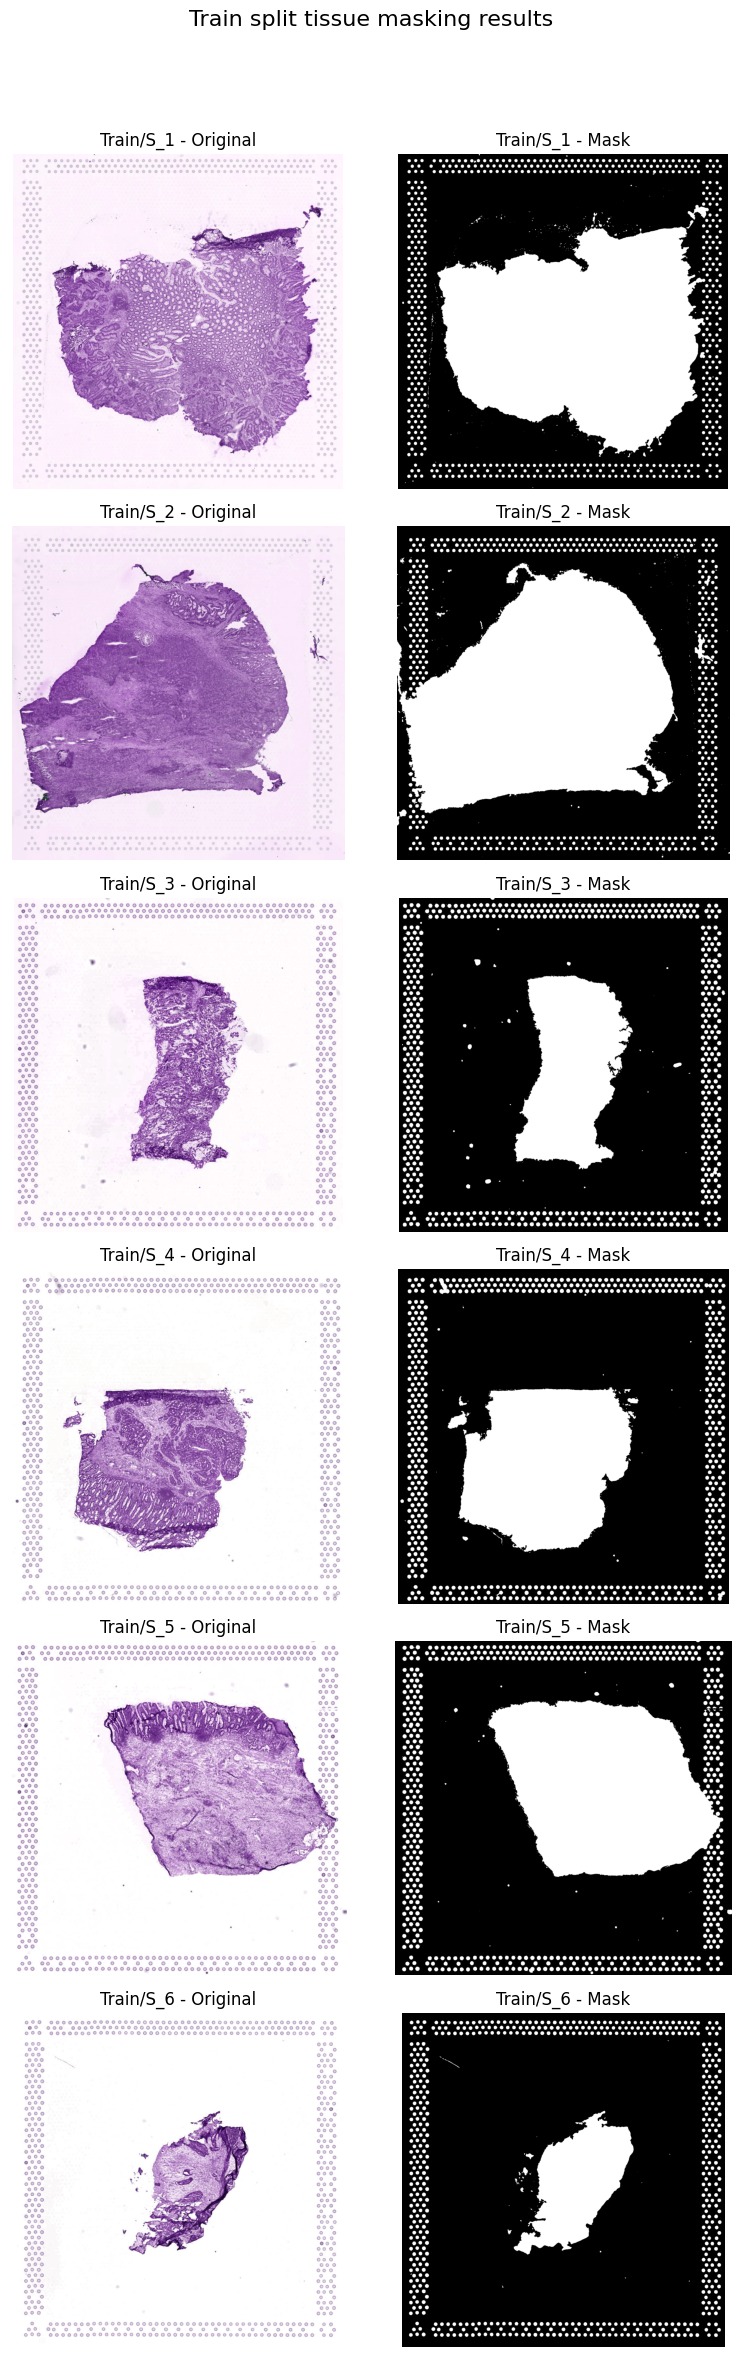

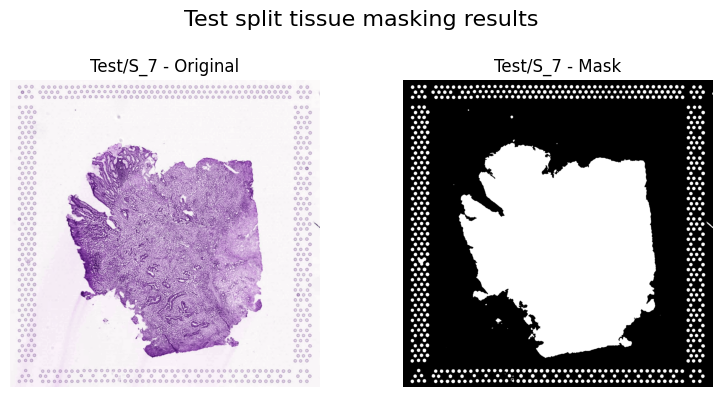

In [3]:

from skimage.color import rgb2gray
from skimage.filters import threshold_mean
from skimage.morphology import closing, remove_small_holes, disk

# Your custom thresholds
custom_thresholds = {
    "S_1": 0.90,
    "S_2": 0.91,
    "S_3": 0.90,
    "S_4": 0.90,
    "S_5": 0.91,
    "S_6": 0.86,
    "S_7": 0.85,
}

with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Image_preprocessing\\try.h5", "r") as h5file:
    # Loop over both Train and Test splits
    for split in ["Train", "Test"]:
        images_grp = h5file[f"images/{split}"]
        slide_ids = sorted(images_grp.keys())

        n = len(slide_ids)
        fig, axs = plt.subplots(nrows=n, ncols=2, figsize=(8, 4 * n))
        if n == 1:
            axs = [axs]

        for i, slide_id in enumerate(slide_ids):
            image = np.array(images_grp[slide_id])
            gray  = rgb2gray(image)

            # 1) Binarize
            thresh = custom_thresholds.get(slide_id, threshold_mean(gray))
            mask   = gray <= thresh  # True = tissue

            # 2) Closing to fill small holes
            mask_closed = closing(mask, disk(2))

            # 3) Fill small holes (area < 5000 px)
            mask_filled = remove_small_holes(
                mask_closed,
                max_size=5000,
                connectivity=2
            )

            # Original
            axs[i][0].imshow(image)
            axs[i][0].set_title(f"{split}/{slide_id} - Original")
            axs[i][0].axis("off")

            # Mask
            axs[i][1].imshow(mask_filled, cmap="gray")
            axs[i][1].set_title(f"{split}/{slide_id} - Mask")
            axs[i][1].axis("off")

        plt.suptitle(f"{split} split tissue masking results", fontsize=16)
        plt.tight_layout(rect=[0,0,1,0.95])
        plt.show()

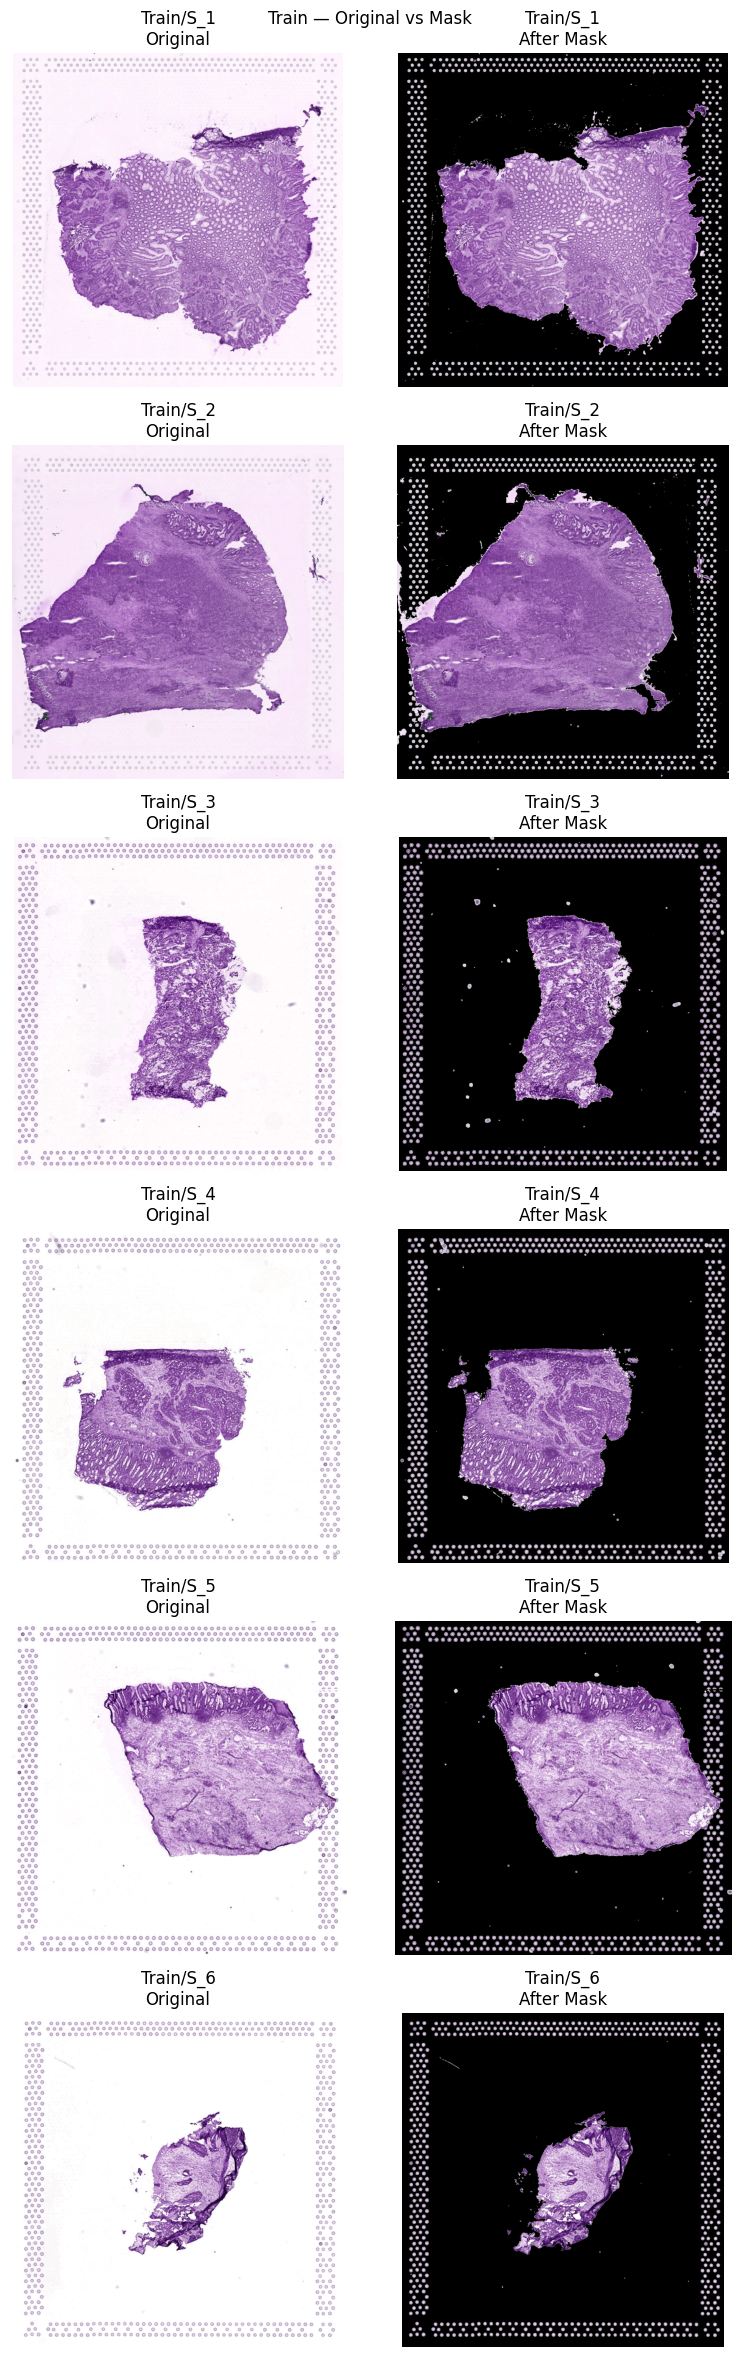

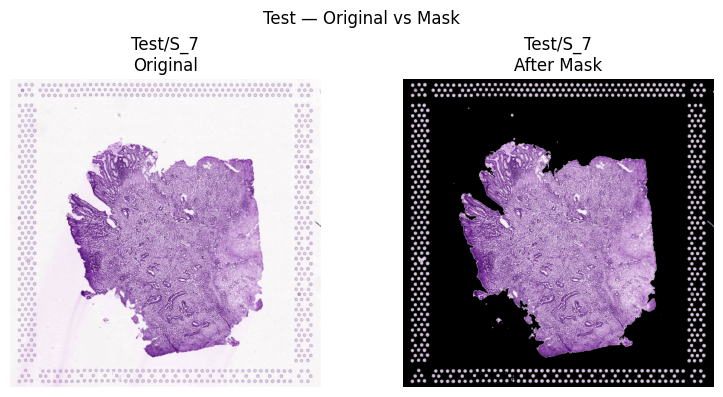

✅ finish masking, save to C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\data_preprocessing\Image_preprocessing\try1_masked.h5


In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.filters import threshold_mean
from skimage.morphology import closing, remove_small_holes, disk
import os

# Custom grayscale threshhold

custom_thresholds = {
    "S_1": 0.90,
    "S_2": 0.91,
    "S_3": 0.90,
    "S_4": 0.90,
    "S_5": 0.91,
    "S_6": 0.86,
    "S_7": 0.85,
}


# input/output 
in_path  = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Image_preprocessing\\try.h5"
out_path = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Image_preprocessing\\try1_masked.h5"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

with h5py.File(in_path,  "r") as h5in, \
     h5py.File(out_path, "w") as h5out:

    for split in ["Train", "Test"]:
        grp_in  = h5in[f"images/{split}"]
        grp_out = h5out.create_group(f"images/{split}")

        slide_ids = list(grp_in.keys())
        n = len(slide_ids)
        fig, axs = plt.subplots(n, 2, figsize=(8, 4*n))
        if n==1: axs = np.expand_dims(axs,0)

        for i, sid in enumerate(slide_ids):
            img = np.array(grp_in[sid])  # float32 [0,1]
            gray = rgb2gray(img)

            # 1) Binarization
            thresh = custom_thresholds.get(sid, threshold_mean(gray))
            mask = gray <= thresh       

            # 2) Closing operation to fill the hole
            mask_closed = closing(mask, disk(2))
            # 3) Fill the remaining hole
            mask_filled = remove_small_holes(
                mask_closed,
                max_size=5000,
                connectivity=2
            )

            # 4) Using mask_filled to set the background to zero(or 1,depending on the requirement)
            masked = img.copy()
            masked[~mask_filled] = 0.0

            # 5) store to a new h5
            grp_out.create_dataset(
                sid,
                data=masked
            )

            # 6) Plots
            ax1, ax2 = axs[i]
            ax1.imshow(img)
            ax1.set_title(f"{split}/{sid}\nOriginal")
            ax1.axis("off")
            ax2.imshow(masked)
            ax2.set_title(f"{split}/{sid}\nAfter Mask")
            ax2.axis("off")

        plt.suptitle(f"{split} — Original vs Mask")
        plt.tight_layout()
        plt.show()

print("✅ finish masking, save to", out_path)